Exploratory Data Analysis (EDA)

In [83]:
import pandas as pd
import numpy as np 

1. Loading CSV files

In [112]:
orders = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\orders.csv")
products = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\products.csv")
aisles = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\aisles.csv")
departments = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\departments.csv")
order_products_train = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\order_products__train.csv")
order_products_prior = pd.read_csv(r"C:\Diploma\Datasets\InstaCart Online Grocery Basket\order_products__prior.csv")

In [113]:
orders.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')

In [114]:
products.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')

In [115]:
aisles.columns

Index(['aisle_id', 'aisle'], dtype='object')

In [116]:
departments.columns

Index(['department_id', 'department'], dtype='object')

In [117]:
order_products_prior.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')

In [118]:
df = pd.merge(orders, order_products_prior)

In [119]:
df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0


In [120]:
df1 = pd.merge(products, df, on='product_id', how='left')

In [121]:
df1.head

<bound method NDFrame.head of           product_id                product_name  aisle_id  department_id  \
0                  1  Chocolate Sandwich Cookies        61             19   
1                  1  Chocolate Sandwich Cookies        61             19   
2                  1  Chocolate Sandwich Cookies        61             19   
3                  1  Chocolate Sandwich Cookies        61             19   
4                  1  Chocolate Sandwich Cookies        61             19   
...              ...                         ...       ...            ...   
32434495       49688      Fresh Foaming Cleanser        73             11   
32434496       49688      Fresh Foaming Cleanser        73             11   
32434497       49688      Fresh Foaming Cleanser        73             11   
32434498       49688      Fresh Foaming Cleanser        73             11   
32434499       49688      Fresh Foaming Cleanser        73             11   

           order_id   user_id eval_set  order

In [122]:
df1 = df.merge(products, on="product_id", how="left")

In [123]:
df1.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2539329,1,prior,1,2,8,NaN,196,1,0,Soda,77,7
1,2539329,1,prior,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,91,16
2,2539329,1,prior,1,2,8,NaN,12427,3,0,Original Beef Jerky,23,19
3,2539329,1,prior,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,23,19
4,2539329,1,prior,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,54,17


In [124]:
df3 = pd.merge(df1, departments, on='department_id', how='left')

In [125]:
df3.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,department
0,2539329,1,prior,1,2,8,NaN,196,1,0,Soda,77,7,beverages
1,2539329,1,prior,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,91,16,dairy eggs
2,2539329,1,prior,1,2,8,NaN,12427,3,0,Original Beef Jerky,23,19,snacks
3,2539329,1,prior,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,23,19,snacks
4,2539329,1,prior,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,54,17,household


In [126]:
cart = pd.merge(df3, aisles, on='aisle_id', how='left')

In [127]:
cart.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,department,aisle
0,2539329,1,prior,1,2,8,NaN,196,1,0,Soda,77,7,beverages,soft drinks
1,2539329,1,prior,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,91,16,dairy eggs,soy lactosefree
2,2539329,1,prior,1,2,8,NaN,12427,3,0,Original Beef Jerky,23,19,snacks,popcorn jerky
3,2539329,1,prior,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,23,19,snacks,popcorn jerky
4,2539329,1,prior,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,54,17,household,paper goods


In [128]:
print(cart.dtypes)

order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
product_name               object
aisle_id                    int64
department_id               int64
department                 object
aisle                      object
dtype: object


In [138]:
print(cart.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
 7   product_id              int64  
 8   add_to_cart_order       int64  
 9   reordered               int64  
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  department              object 
 14  aisle                   object 
dtypes: float64(1), int64(10), object(4)
memory usage: 3.6+ GB
None


In [129]:
print(cart.isna().sum())

order_id                        0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_id                      0
add_to_cart_order               0
reordered                       0
product_name                    0
aisle_id                        0
department_id                   0
department                      0
aisle                           0
dtype: int64


In [130]:
cart['days_since_prior_order'] = cart['days_since_prior_order'].fillna(0)

In [131]:
print(cart.isna().sum())

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
department                0
aisle                     0
dtype: int64


Missing values in `days_since_prior_order` correspond to the first order of a user.
They are replaced with 0 to indicate no prior purchase history.

now we check unique objects 

In [ ]:
# одинаковые строки
print("Полные дубликаты:", cart.duplicated().sum())

#дубликаты по заказам (order_id + product_id)?
print("Дубликаты order_id + product_id:", cart.duplicated(subset=['order_id','product_id']).sum())


Полные дубликаты: 0
Дубликаты order_id + product_id: 0


In [141]:
print(cart.describe())

           order_id       user_id  order_number     order_dow  \
count  3.243449e+07  3.243449e+07  3.243449e+07  3.243449e+07   
mean   1.710749e+06  1.029372e+05  1.714205e+01  2.738818e+00   
std    9.873007e+05  5.946648e+04  1.753504e+01  2.090049e+00   
min    2.000000e+00  1.000000e+00  1.000000e+00  0.000000e+00   
25%    8.559430e+05  5.142100e+04  5.000000e+00  1.000000e+00   
50%    1.711048e+06  1.026110e+05  1.100000e+01  3.000000e+00   
75%    2.565514e+06  1.543910e+05  2.400000e+01  5.000000e+00   
max    3.421083e+06  2.062090e+05  9.900000e+01  6.000000e+00   

       order_hour_of_day  days_since_prior_order    product_id  \
count       3.243449e+07            3.243449e+07  3.243449e+07   
mean        1.342498e+01            1.039264e+01  2.557634e+04   
std         4.246365e+00            8.917691e+00  1.409669e+04   
min         0.000000e+00            0.000000e+00  1.000000e+00   
25%         1.000000e+01            4.000000e+00  1.353000e+04   
50%         1.3000

In [142]:
for col in ['eval_set', 'department', 'aisle', 'product_name']:
    print(f"{col}: {cart[col].nunique()} уникальных значений")

eval_set: 1 уникальных значений
department: 21 уникальных значений
aisle: 134 уникальных значений
product_name: 49677 уникальных значений


In [143]:
print(cart.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
 7   product_id              int64  
 8   add_to_cart_order       int64  
 9   reordered               int64  
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  department              object 
 14  aisle                   object 
dtypes: float64(1), int64(10), object(4)
memory usage: 3.6+ GB
None


In [144]:
print(cart.nunique().sort_values())

eval_set                        1
reordered                       2
order_dow                       7
department_id                  21
department                     21
order_hour_of_day              24
days_since_prior_order         31
order_number                   99
aisle                         134
aisle_id                      134
add_to_cart_order             145
product_id                  49677
product_name                49677
user_id                    206209
order_id                  3214874
dtype: int64


Выбираем пользователей

Проверить распределение заказов на пользователя и времени между заказами:

In [148]:
import matplotlib.pyplot as plt

In [149]:
user_orders_max = cart.groupby('user_id')['order_number'].max()

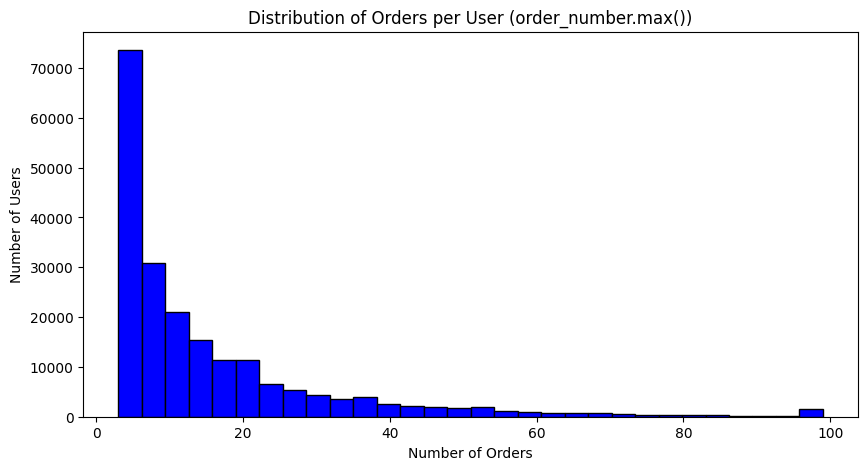

In [153]:
plt.figure(figsize=(10,5))
plt.hist(user_orders_max, bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Orders per User (order_number.max())')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Users')
plt.show()

In [156]:
threshold = np.percentile(user_orders_max, 60)  # верхние 40% пользователей
print(threshold)

12.0


Все пользователи с заказов ≥ threshold — активные.

In [157]:
# Порог активности
threshold = 12  # 60-й процентиль

# Список активных пользователей
active_users = user_orders_max[user_orders_max >= threshold].index

# Новый датасет только с активными пользователями
cart_active = cart[cart['user_id'].isin(active_users)]

print(f"Number of active users: {len(active_users)}")

Number of active users: 86929


In [159]:
import seaborn as sns

In [160]:
active_user_orders = cart_active.groupby('user_id')['order_number'].max()

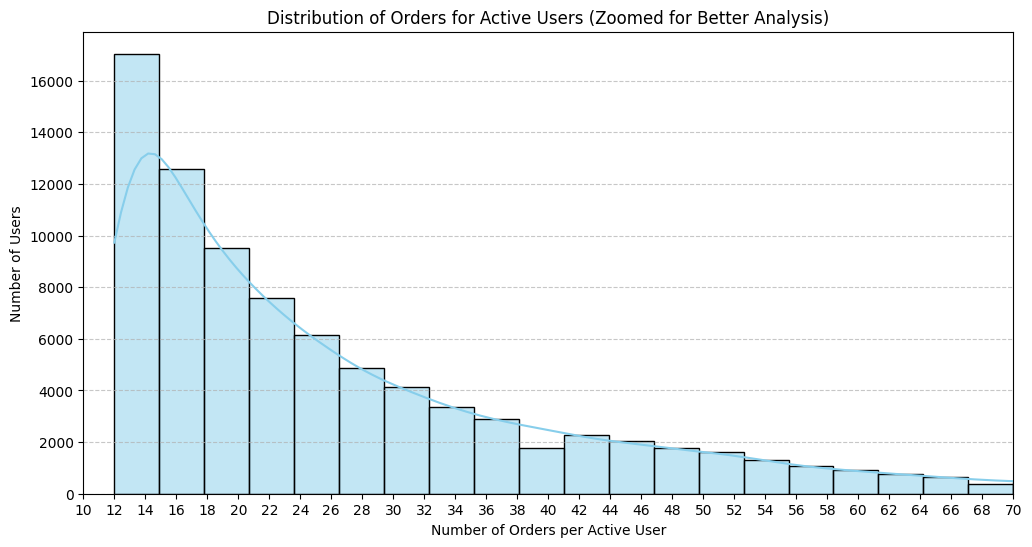

In [161]:
plt.figure(figsize=(12,6))
sns.histplot(active_user_orders, bins=30, kde=True, color='skyblue', edgecolor='black')

# Ограничим x, чтобы сосредоточиться на большинстве пользователей
plt.xlim(10, active_user_orders.quantile(0.95))  # zoom на пользователей с 10 до 95 перцентиля
plt.xticks(range(10, int(active_user_orders.quantile(0.95))+2, 2))  # делаем отметки через 2 заказа для читаемости

plt.xlabel("Number of Orders per Active User")
plt.ylabel("Number of Users")
plt.title("Distribution of Orders for Active Users (Zoomed for Better Analysis)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [162]:
cart_active.to_csv('cart_active_users.csv', index=False)